In [1]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import math

# import a lot of things from keras:
# sequential model
import keras
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness, BatchNormalization, GlobalAveragePooling2D

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['dislike','like','rock','peace','stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

## helper function to load and parse annotations

In [2]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [3]:
# pretty-print first element
#print(json.dumps(annotations['like']['004b66dd-19e0-47cd-968e-c1b56f9e9179'], indent=2))

## helper function to pre-process images (color channel conversion and resizing)

In [4]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [5]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(condition)):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label == "no_gesture":
                continue
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

X = np.array(images)
y = np.array(labels)
X_test = X
y_test = y

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

## let's have a look at one of the images

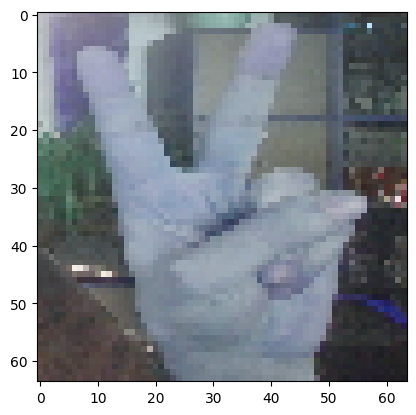

In [6]:
plt.imshow(random.sample(images, 1)[0])

In [7]:
X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.

y_test_one_hot = to_categorical(y_test)

test_label = y_test_one_hot

X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_test.shape, test_label.shape)

(15, 64, 64, 3) (15, 5)


## visualize classification results with a confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
before [[9.9968457e-01 2.9560027e-07 2.6082093e-04 4.1118004e-05 1.3100281e-05]
 [9.9889523e-01 4.5387092e-04 7.3758427e-05 2.2338188e-04 3.5388555e-04]
 [9.9978846e-01 1.6778644e-06 4.4448647e-05 1.3714026e-04 2.8215793e-05]
 [1.9352694e-05 9.9640852e-01 1.8409672e-05 2.0624660e-03 1.4911973e-03]
 [1.9335576e-03 9.4502455e-01 3.9441374e-04 3.2778524e-02 1.9868895e-02]
 [8.7521294e-05 9.7599822e-01 6.1139481e-06 2.3058372e-02 8.4983924e-04]
 [6.7468826e-03 1.0637765e-05 8.4885508e-01 1.4223574e-01 2.1516706e-03]
 [2.0529817e-06 3.3037301e-07 9.9996829e-01 2.5895688e-05 3.3976660e-06]
 [1.5847453e-04 2.4459395e-04 9.7884858e-01 2.0646265e-02 1.0206845e-04]
 [1.1316310e-02 1.3562182e-02 8.4994901e-03 9.4748986e-01 1.9132124e-02]
 [7.2952936e-08 4.8161803e-07 6.8776576e-06 9.9998987e-01 2.7353076e-06]
 [5.5572618e-04 7.3075484e-05 4.6183113e-02 9.5289683e-01 2.9128374e-04]
 [1.4982617e-03 3.1499038e-04 1.0022003e-03 1.2107672e-03 9.9597377e-01]
 [1.3

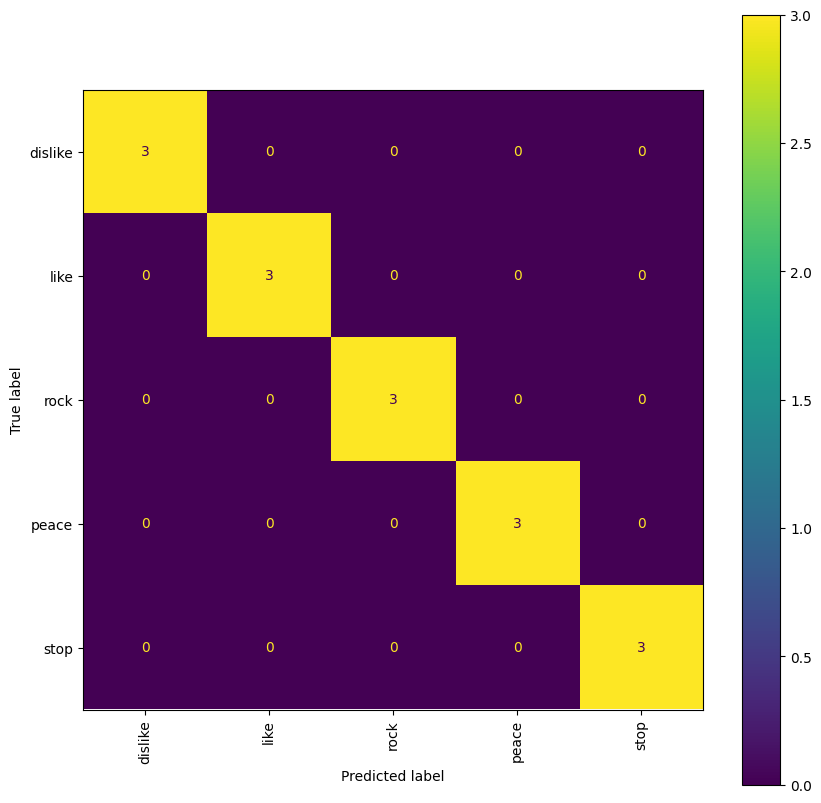

In [8]:
model = keras.models.load_model("gesture_recognition_64_FOR_TASK_2.keras")
# let the model make predictions for our training data
y_predictions = model.predict(X_test)

# we get a 2D numpy array with probabilities for each category
print('before', y_predictions)

# to build a confusion matrix, we have to convert it to classifications
# this can be done by using the argmax() function to set the probability to 1 and the rest to 0
y_predictions = np.argmax(y_predictions, axis=1)

print('probabilities', y_predictions)

# create and plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_predictions)

fig = plt.figure(figsize=(10, 10))

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')
pass



In [ ]:
plt.savefig("conf-matrix.png", dpi=300, bbox_inches="tight")